In [ ]:
import warnings, time, numpy as np, pandas as pd, matplotlib.pyplot as plt
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

### Load Dataset

In [ ]:
import requests

# Download the wdbc.data file
!wget https://archive.ics.uci.edu/ml/machine-learning-databases/breast-cancer-wisconsin/wdbc.data

columns = [
"ID","Diagnosis",
"Mean Radius","Mean Texture","Mean Perimeter","Mean Area","Mean Smoothness",
"Mean Compactness","Mean Concavity","Mean Concave Points","Mean Symmetry","Mean Fractal Dimension",
"Radius SE","Texture SE","Perimeter SE","Area SE","Smoothness SE",
"Compactness SE","Concavity SE","Concave Points SE","Symmetry SE","Fractal Dimension SE",
"Worst Radius","Worst Texture","Worst Perimeter","Worst Area","Worst Smoothness",
"Worst Compactness","Worst Concavity","Worst Concave Points","Worst Symmetry","Worst Fractal Dimension"
]

df = pd.read_csv("wdbc.data", header=None, names=columns)

print("\nDataset Shape :", df.shape)
df.head()

--2026-07-26 13:16:29--  https://archive.ics.uci.edu/ml/machine-learning-databases/breast-cancer-wisconsin/wdbc.data
Resolving archive.ics.uci.edu (archive.ics.uci.edu)... 128.195.10.252
Connecting to archive.ics.uci.edu (archive.ics.uci.edu)|128.195.10.252|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified
Saving to: ‘wdbc.data’

wdbc.data               [   <=>              ] 121.19K   245KB/s    in 0.5s    

2026-07-26 13:16:30 (245 KB/s) - ‘wdbc.data’ saved [124103]


Dataset Shape : (569, 32)


,ID,Diagnosis,Mean Radius,Mean Texture,Mean Perimeter,Mean Area,Mean Smoothness,Mean Compactness,Mean Concavity,Mean Concave Points,...,Worst Radius,Worst Texture,Worst Perimeter,Worst Area,Worst Smoothness,Worst Compactness,Worst Concavity,Worst Concave Points,Worst Symmetry,Worst Fractal Dimension
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


### Preprocessing

In [ ]:
df.drop("ID", axis=1, inplace=True)

encoder = LabelEncoder()
df["Diagnosis"] = encoder.fit_transform(df["Diagnosis"])   # B=0, M=1

X = df.drop("Diagnosis", axis=1)
y = df["Diagnosis"]
feature_names = X.columns.tolist()

print("\nMissing Values\n", df.isnull().sum())
print("\nDiagnosis Distribution\n", df["Diagnosis"].value_counts())


Missing Values
 Diagnosis                  0
Mean Radius                0
Mean Texture               0
Mean Perimeter             0
Mean Area                  0
Mean Smoothness            0
Mean Compactness           0
Mean Concavity             0
Mean Concave Points        0
Mean Symmetry              0
Mean Fractal Dimension     0
Radius SE                  0
Texture SE                 0
Perimeter SE               0
Area SE                    0
Smoothness SE              0
Compactness SE             0
Concavity SE               0
Concave Points SE          0
Symmetry SE                0
Fractal Dimension SE       0
Worst Radius               0
Worst Texture              0
Worst Perimeter            0
Worst Area                 0
Worst Smoothness           0
Worst Compactness          0
Worst Concavity            0
Worst Concave Points       0
Worst Symmetry             0
Worst Fractal Dimension    0
dtype: int64

Diagnosis Distribution
 Diagnosis
0    357
1    212
Name: count, dtype

### Train/Test Split & Scaling

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"\nTraining Samples : {len(X_train)}")
print(f"Testing Samples  : {len(X_test)}")


Training Samples : 455
Testing Samples  : 114


### Train & Evaluate ML Models

In [ ]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
    "SVM": SVC(probability=True, random_state=42)
}

results, trained_models = [], {}

for name, model in models.items():

    start = time.time()

    model.fit(X_train_scaled, y_train)

    trained_models[name] = model

    pred = model.predict(X_test_scaled)
    prob = model.predict_proba(X_test_scaled)[:,1]

    results.append([
        name,
        accuracy_score(y_test,pred),
        precision_score(y_test,pred),
        recall_score(y_test,pred),
        f1_score(y_test,pred),
        roc_auc_score(y_test,prob),
        time.time()-start
    ])

results_df = pd.DataFrame(results, columns=[
    "Model","Accuracy","Precision","Recall","F1","AUC","Time"
]).sort_values("Accuracy", ascending=False)

print("\nModel Performance")
results_df


Model Performance


,Model,Accuracy,Precision,Recall,F1,AUC,Time
3,SVM,0.973684,1.000000,0.928571,0.962963,0.994709,0.044849
0,Logistic Regression,0.964912,0.975000,0.928571,0.951220,0.996032,0.048232
2,Random Forest,0.964912,1.000000,0.904762,0.950000,0.994213,0.743812
1,Decision Tree,0.929825,0.904762,0.904762,0.904762,0.924603,0.064337


In [ ]:
best_model_name = results_df.iloc[0]["Model"]
best_model = trained_models[best_model_name]

print(f"\nBest Model : {best_model_name}")


Best Model : SVM


### SHAP Feature Attribution

In [ ]:
import shap

            Feature      SHAP
23       Worst Area  0.117295
22  Worst Perimeter  0.109664
20     Worst Radius  0.091160
13          Area SE  0.059444
3         Mean Area  0.056967


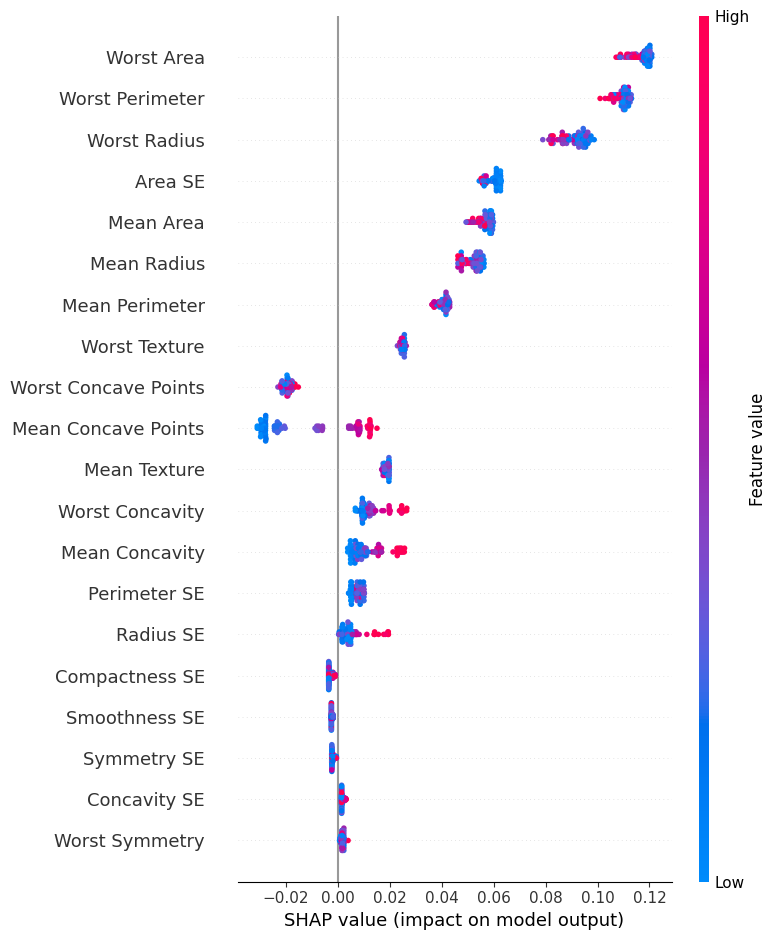

In [ ]:
shap_model = best_model if best_model_name == "Random Forest" else trained_models["Random Forest"]

explainer = shap.TreeExplainer(shap_model)
shap_values = explainer.shap_values(X_test)


if isinstance(shap_values, list):

    shap_val = shap_values[1]
elif len(shap_values.shape) == 3:

    shap_val = shap_values[:, :, 1]
else:
    shap_val = shap_values


importance = np.abs(shap_val).mean(axis=0)

shap_importance = pd.DataFrame({
    "Feature": feature_names,
    "SHAP": importance
}).sort_values("SHAP", ascending=False)

print(shap_importance.head())

shap.summary_plot(shap_val, X_test, show=False)
plt.tight_layout()
plt.savefig("SHAP_Summary.png")
plt.show()

### Global LIME Feature Attribution

In [ ]:
!pip install lime
from lime.lime_tabular import LimeTabularExplainer
from collections import defaultdict

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 23.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=022ae7818864643bc22972e7f8f72dfcb8df870a0d07b910ed55635d6863d5c6
  Stored in directory: /root/.cache/pip/wheels/e7/5d/0e/4b4fff9a47468fed5633211fb3b76d1db43fe806a17fb7486a
Successfully built lime


In [ ]:
lime = LimeTabularExplainer(
    X_train_scaled,
    feature_names=feature_names,
    class_names=["Benign","Malignant"],
    mode="classification"
)

scores=defaultdict(list)

for i in range(min(50,len(X_test_scaled))):

    exp=lime.explain_instance(
        X_test_scaled[i],
        best_model.predict_proba,
        num_features=len(feature_names)
    )

    for f,w in exp.as_list():

        for name in feature_names:
            if name in f:
                scores[name].append(abs(w))
                break

global_lime=pd.DataFrame({
    "Feature":feature_names,
    "LIME":[np.mean(scores[f]) if len(scores[f]) else 0 for f in feature_names]
}).sort_values("LIME",ascending=False)

print("\nTop LIME Features")
print(global_lime.head())


Top LIME Features
           Feature      LIME
21   Worst Texture  0.110015
1     Mean Texture  0.071358
20    Worst Radius  0.066357
23      Worst Area  0.065680
28  Worst Symmetry  0.062878


### Permutation Importance

In [ ]:
from sklearn.inspection import permutation_importance

In [ ]:
perm=permutation_importance(
    best_model,
    X_test_scaled,
    y_test,
    n_repeats=20,
    random_state=42
)

perm_importance=pd.DataFrame({
    "Feature":feature_names,
    "Permutation":perm.importances_mean
}).sort_values("Permutation",ascending=False)

print("\nTop Permutation Features")
print(perm_importance.head())


Top Permutation Features
                   Feature  Permutation
21           Worst Texture     0.022807
9   Mean Fractal Dimension     0.017105
27    Worst Concave Points     0.015789
18             Symmetry SE     0.013596
14           Smoothness SE     0.012719


### Compare XAI Methods

In [ ]:
compare=shap_importance.merge(global_lime,on="Feature").merge(
    perm_importance,on="Feature"
)

print("\nCombined Comparison")
print(compare.head())


Combined Comparison
           Feature      SHAP      LIME  Permutation
0       Worst Area  0.117295  0.065680     0.011842
1  Worst Perimeter  0.109664  0.062660     0.011404
2     Worst Radius  0.091160  0.066357     0.011842
3          Area SE  0.059444  0.052116     0.010088
4        Mean Area  0.056967  0.048571     0.011842


### Correlation Analysis

In [ ]:
from scipy.stats import spearmanr,kendalltau

In [ ]:
print("\nSpearman Correlation")

print("SHAP vs LIME :",
      round(spearmanr(compare["SHAP"],compare["LIME"])[0],4))

print("SHAP vs Perm :",
      round(spearmanr(compare["SHAP"],compare["Permutation"])[0],4))

print("LIME vs Perm :",
      round(spearmanr(compare["LIME"],compare["Permutation"])[0],4))

print("\nKendall Tau")

print("SHAP vs LIME :",
      round(kendalltau(compare["SHAP"],compare["LIME"])[0],4))

print("SHAP vs Perm :",
      round(kendalltau(compare["SHAP"],compare["Permutation"])[0],4))

print("LIME vs Perm :",
      round(kendalltau(compare["LIME"],compare["Permutation"])[0],4))


Spearman Correlation
SHAP vs LIME : 0.6761
SHAP vs Perm : 0.4287
LIME vs Perm : 0.3022

Kendall Tau
SHAP vs LIME : 0.4621
SHAP vs Perm : 0.314
LIME vs Perm : 0.2302


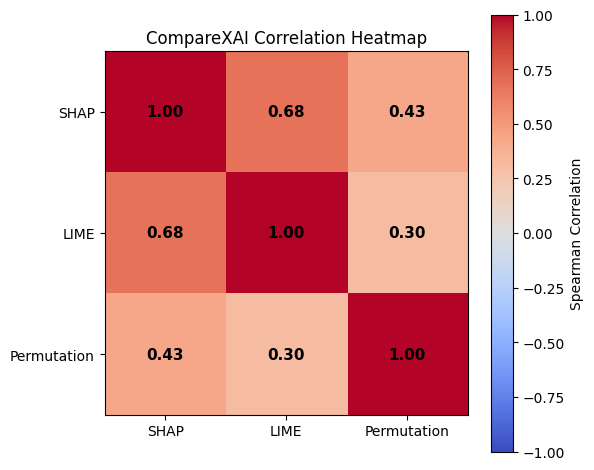

In [ ]:
corr = compare[["SHAP", "LIME", "Permutation"]].corr(method="spearman")

plt.figure(figsize=(6,5))

plt.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)

plt.xticks(range(len(corr.columns)), corr.columns)
plt.yticks(range(len(corr.columns)), corr.columns)


for i in range(len(corr.index)):
    for j in range(len(corr.columns)):
        plt.text(
            j, i,
            f"{corr.iloc[i, j]:.2f}",
            ha="center",
            va="center",
            color="black",
            fontsize=11,
            fontweight="bold"
        )

plt.colorbar(label="Spearman Correlation")
plt.title("CompareXAI Correlation Heatmap")
plt.tight_layout()
plt.savefig("Correlation.png", dpi=300)
plt.show()

### Top-K Feature Agreement


Top-K Agreement
         Comparison  Overlap  Agreement %
0         SHAP-LIME        6         60.0
1  SHAP-Permutation        6         60.0
2  LIME-Permutation        5         50.0


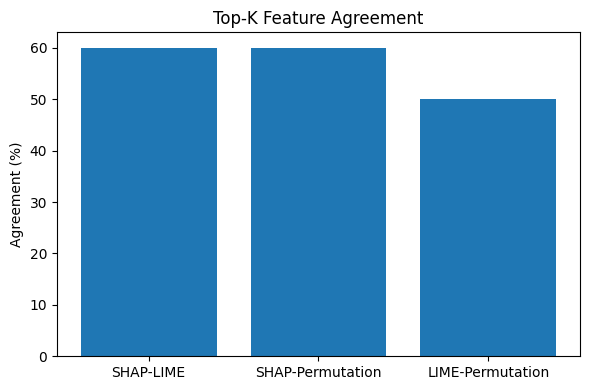

In [ ]:
K=10

shap_top=set(shap_importance.head(K)["Feature"])
lime_top=set(global_lime.head(K)["Feature"])
perm_top=set(perm_importance.head(K)["Feature"])

agreement=pd.DataFrame({
    "Comparison":["SHAP-LIME","SHAP-Permutation","LIME-Permutation"],
    "Overlap":[
        len(shap_top&lime_top),
        len(shap_top&perm_top),
        len(lime_top&perm_top)
    ]
})

agreement["Agreement %"]=agreement["Overlap"]/K*100

print("\nTop-K Agreement")
print(agreement)

plt.figure(figsize=(6,4))
plt.bar(agreement["Comparison"],agreement["Agreement %"])
plt.ylabel("Agreement (%)")
plt.title("Top-K Feature Agreement")
plt.tight_layout()
plt.savefig("TopK_Agreement.png")
plt.show()

### Runtime Comparison

In [ ]:
import time

runtime=[]

In [ ]:
# SHAP
t=time.time()
explainer=shap.TreeExplainer(shap_model)
explainer.shap_values(X_test)
runtime.append(["SHAP",time.time()-t])

# LIME
t=time.time()
lime.explain_instance(
    X_test_scaled[0],
    best_model.predict_proba,
    num_features=10
)
runtime.append(["LIME",time.time()-t])

# Permutation
t=time.time()
permutation_importance(best_model,X_test_scaled,y_test,n_repeats=10)
runtime.append(["Permutation",time.time()-t])

runtime_df=pd.DataFrame(runtime,columns=["Method","Seconds"])

print("\nRuntime")
print(runtime_df)


Runtime
        Method   Seconds
0         SHAP  0.083620
1         LIME  0.107429
2  Permutation  0.614508


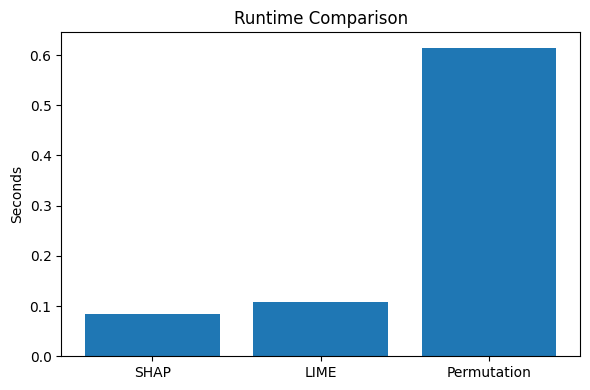

In [ ]:
plt.figure(figsize=(6,4))
plt.bar(runtime_df["Method"],runtime_df["Seconds"])
plt.ylabel("Seconds")
plt.title("Runtime Comparison")
plt.tight_layout()
plt.savefig("Runtime.png")
plt.show()

### ROAR Evaluation

In [ ]:
from sklearn.base import clone

In [ ]:
remove=[1,3,5,10]
roar=[]

for n in remove:

    drop=shap_importance.head(n)["Feature"]

    Xt_train=X_train.drop(columns=drop)
    Xt_test=X_test.drop(columns=drop)

    sc=StandardScaler()

    Xt_train=sc.fit_transform(Xt_train)
    Xt_test=sc.transform(Xt_test)

    model=clone(best_model)
    model.fit(Xt_train,y_train)

    pred=model.predict(Xt_test)

    roar.append([n,accuracy_score(y_test,pred)])

roar_df=pd.DataFrame(roar,columns=["Removed Features","Accuracy"])

print("\nROAR")
print(roar_df)


ROAR
   Removed Features  Accuracy
0                 1  0.964912
1                 3  0.964912
2                 5  0.964912
3                10  0.964912


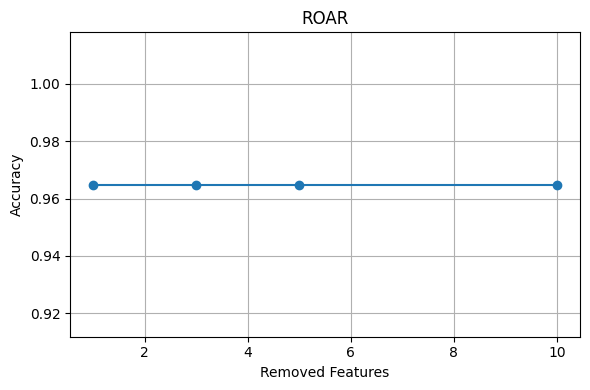

In [ ]:
plt.figure(figsize=(6,4))
plt.plot(roar_df["Removed Features"],roar_df["Accuracy"],marker="o")
plt.xlabel("Removed Features")
plt.ylabel("Accuracy")
plt.title("ROAR")
plt.grid()
plt.tight_layout()
plt.savefig("ROAR.png")
plt.show()

### Final Comparison Summary

In [ ]:
summary=pd.DataFrame({

    "Method":[
        "SHAP",
        "Global LIME",
        "Permutation"
    ],

    "Top Feature":[
        shap_importance.iloc[0]["Feature"],
        global_lime.iloc[0]["Feature"],
        perm_importance.iloc[0]["Feature"]
    ],

    "Runtime (s)":[
        runtime_df.iloc[0]["Seconds"],
        runtime_df.iloc[1]["Seconds"],
        runtime_df.iloc[2]["Seconds"]
    ]
})

print("\nFinal CompareXAI Summary")
print(summary)


Final CompareXAI Summary
        Method    Top Feature  Runtime (s)
0         SHAP     Worst Area     0.083620
1  Global LIME  Worst Texture     0.107429
2  Permutation  Worst Texture     0.614508
